## Regression setup

In [1]:
N_LAYERS = 36

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm
import json, os, gc
from datasets import load_dataset
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

# ====================== CONFIG ======================
MODEL_NAME = "Qwen/Qwen3-4B"
DEVICE = "cuda"
BATCH_SIZE = 8          # Very conservative for 8B
EPOCHS = 16
LR = 5e-4

ACTIVATION_TYPES = [
    "resid_post",
    'resid_mid',
                     "mlp_post", 
                     "attn_out"
                     ]  # Add more as needed


SAVE_DIR = "./real-toxicity-prompts"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
N_SAMPLES = 16000

In [5]:
from datasets import load_dataset


print("Loading real-toxicity-prompts")

    # Note: You may need to accept terms on HuggingFace first
ds = load_dataset("allenai/real-toxicity-prompts", split="train")
    
harmful_texts = []
benign_texts = []
    



Loading real-toxicity-prompts


In [6]:
TARGETS = list(ds[0]['prompt'].keys())[1:]

Extracting characteristics...
Collected 8001 samples


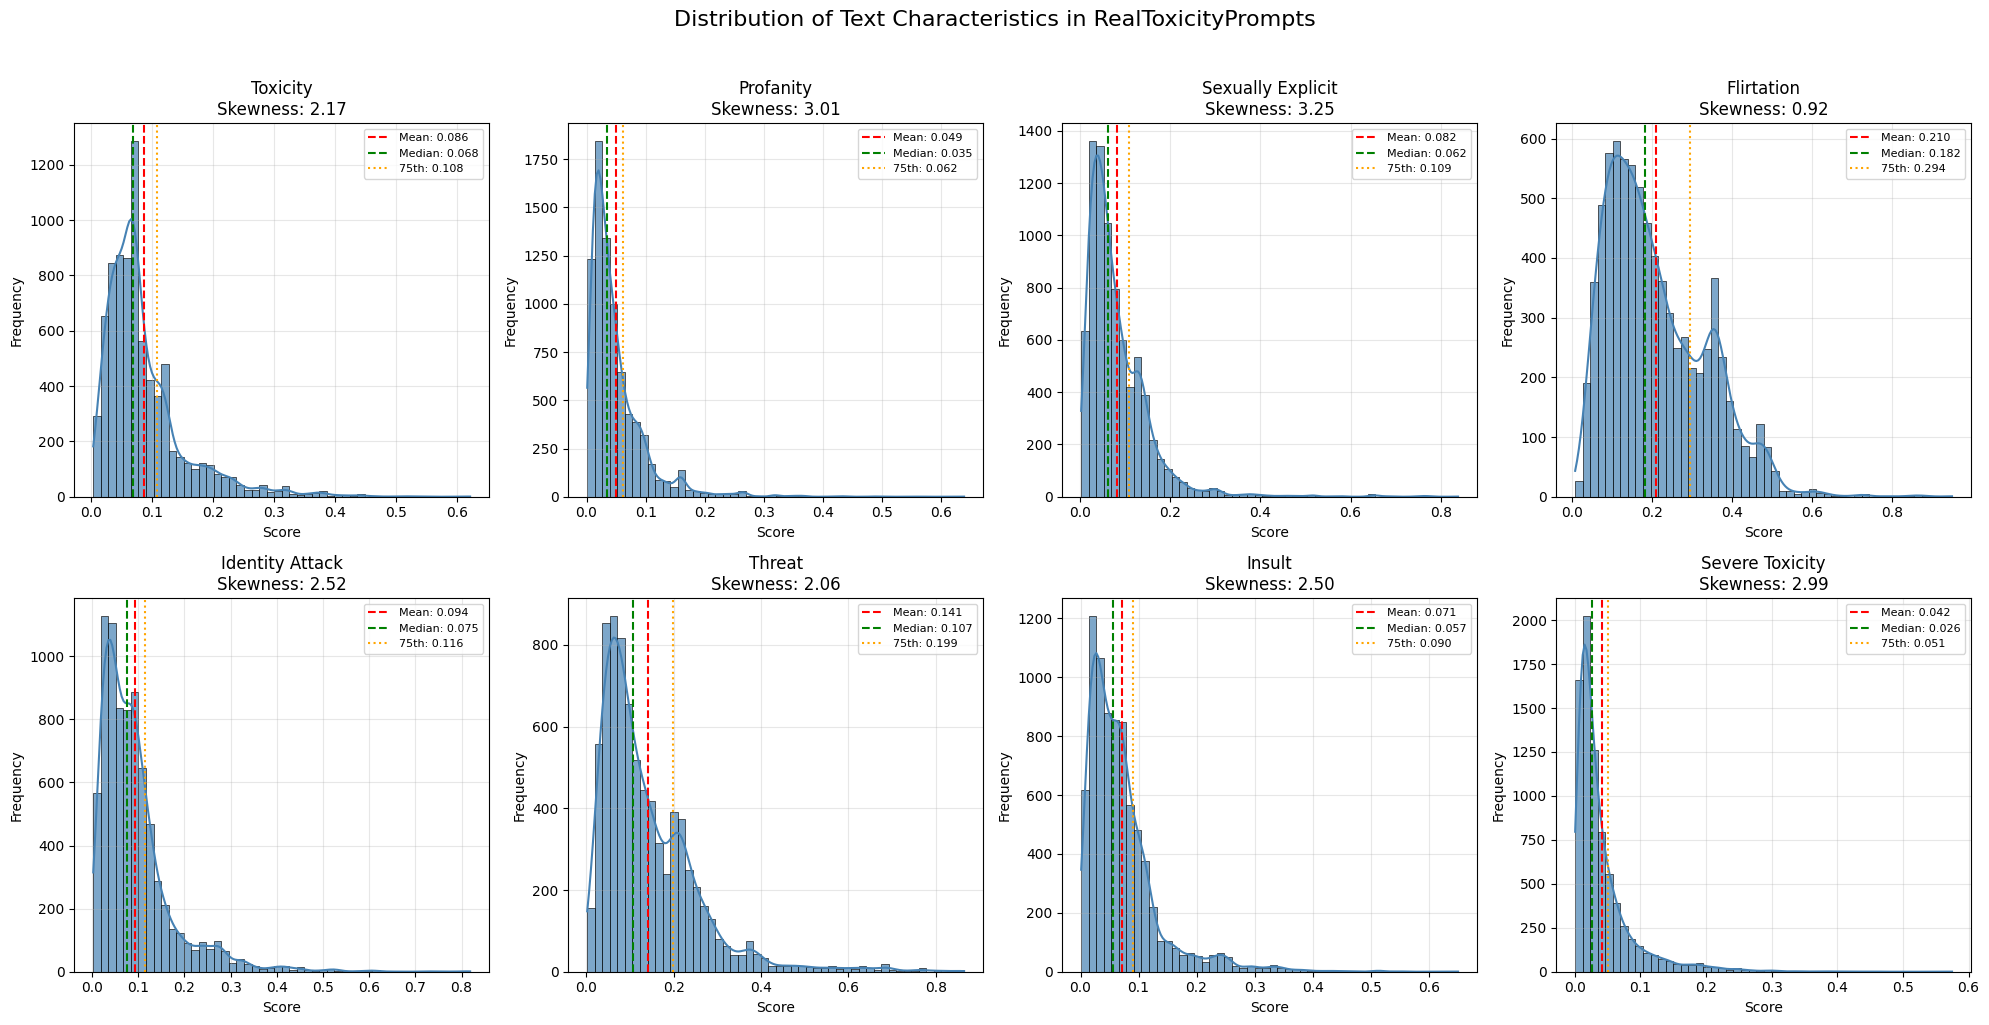


STATISTICAL SUMMARY
   Characteristic   Mean Median    Std Skewness Kurtosis 95th Percentile 99th Percentile
         toxicity 0.0863 0.0685 0.0674    2.174    6.655          0.2243          0.3503
        profanity 0.0491 0.0346 0.0480    3.013   15.429          0.1416          0.2503
sexually_explicit 0.0816 0.0621 0.0707    3.250   19.531          0.1952          0.3429
       flirtation 0.2105 0.1819 0.1236    0.918    0.935          0.4398          0.5156
  identity_attack 0.0938 0.0753 0.0818    2.518   10.028          0.2620          0.4137
           threat 0.1408 0.1075 0.1128    2.064    6.408          0.3496          0.6064
           insult 0.0710 0.0566 0.0634    2.500    9.439          0.2004          0.3275
  severe_toxicity 0.0417 0.0257 0.0473    2.989   12.925          0.1372          0.2347

THRESHOLD ESTIMATION

Recommended thresholds (by method):

   Characteristic Mean+1σ 75th %ile 90th %ile 95th %ile IQR (Q3+1.5*IQR)
         toxicity  0.1537    0.1077    0.1741

/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leostre/Рабочий стол/evals_project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

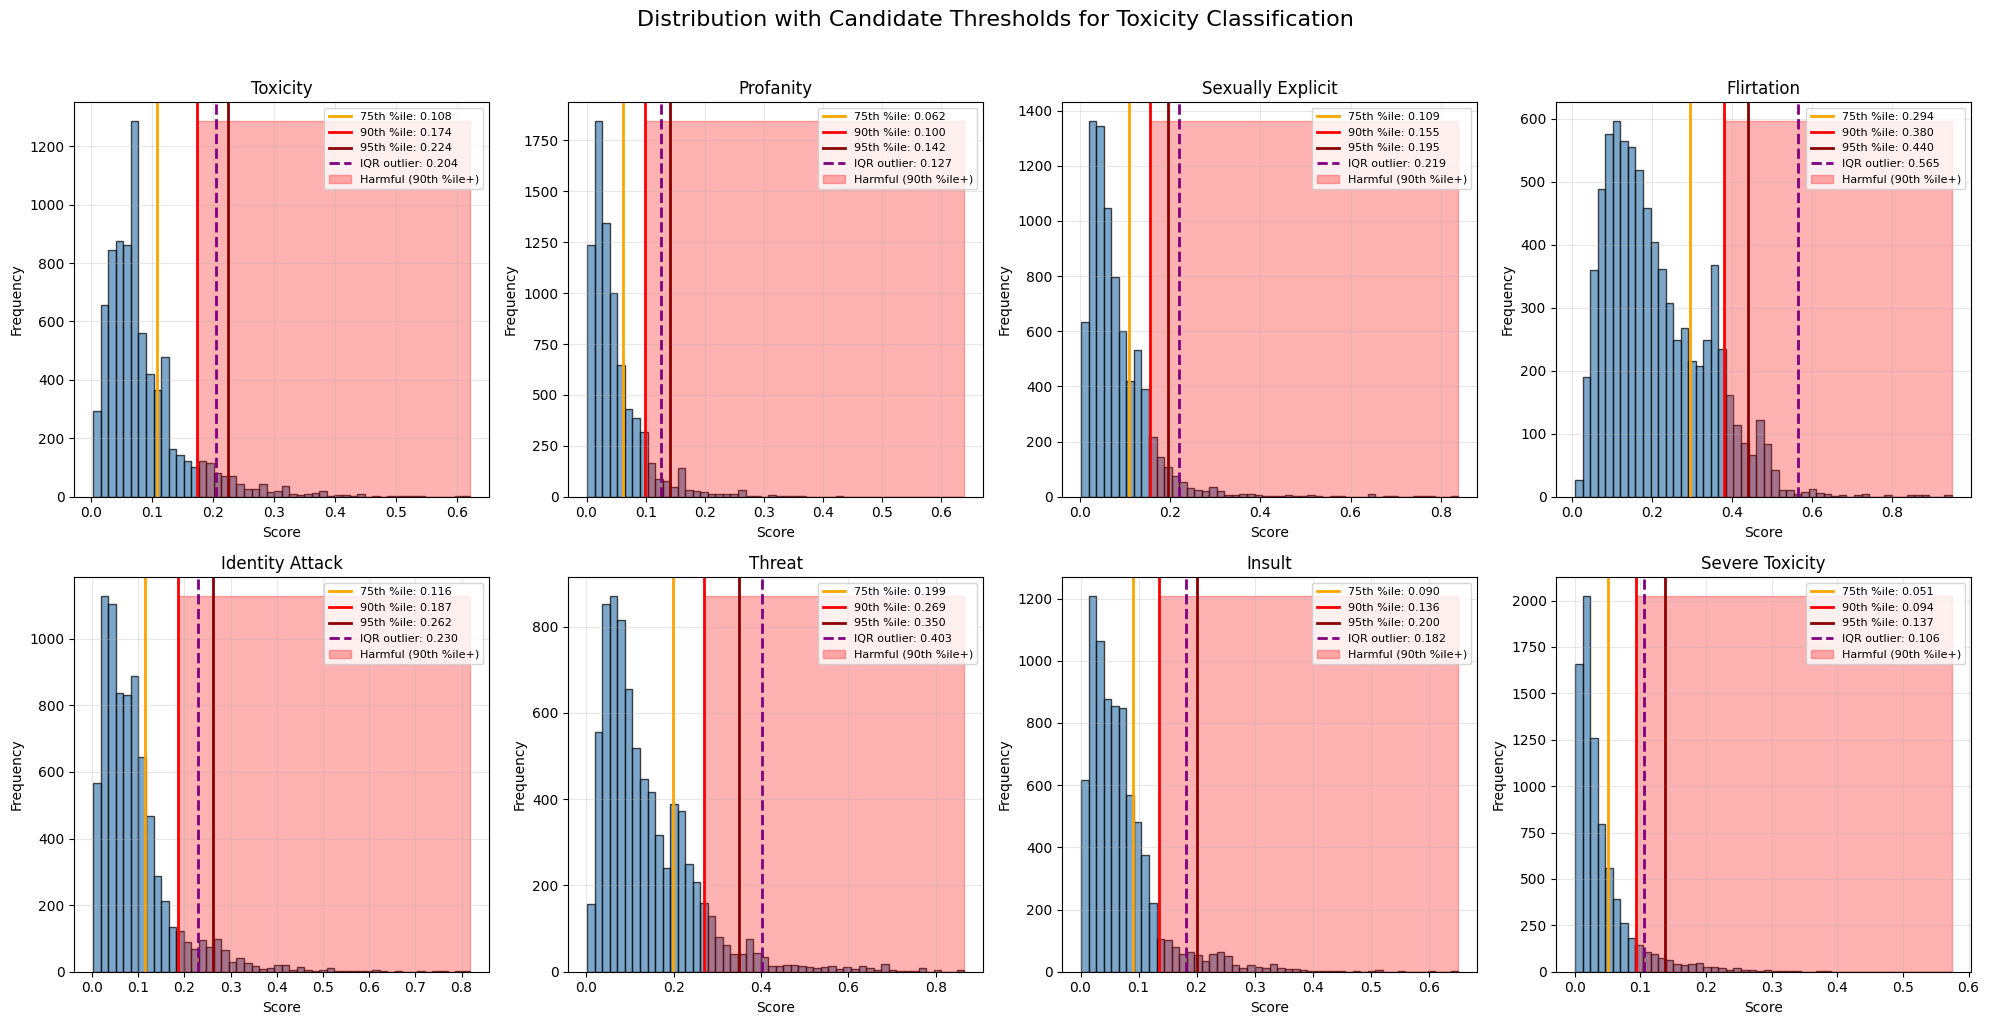

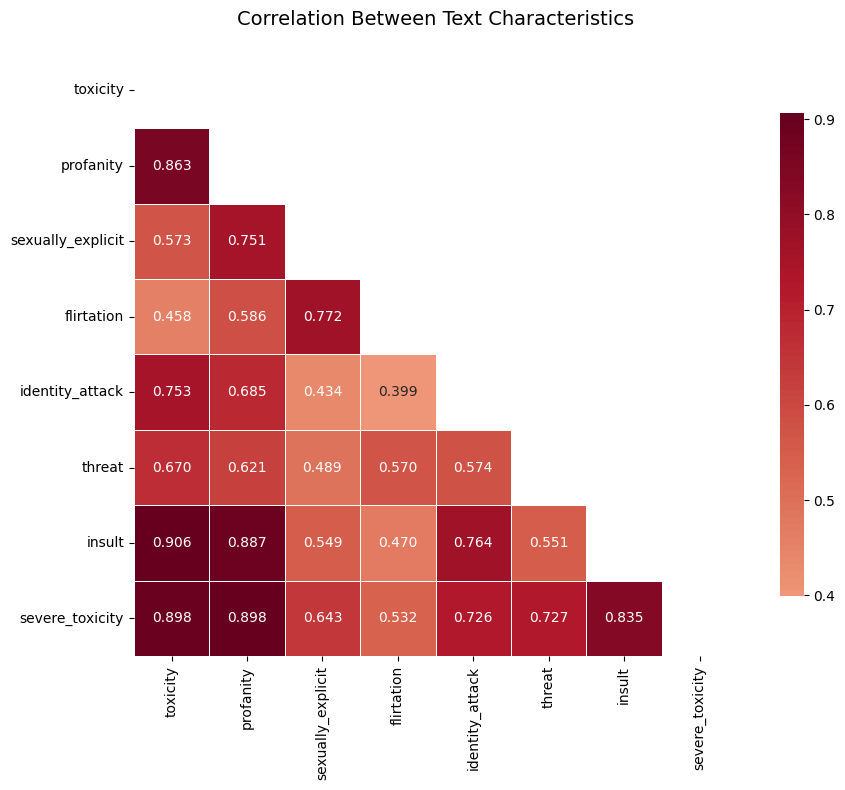

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from scipy import stats



# Extract all text characteristics
characteristics = ['toxicity', 'profanity', 'sexually_explicit', 'flirtation', 
                   'identity_attack', 'threat', 'insult', 'severe_toxicity']

# Collect data from prompts (since your example shows prompt has the main scores)
data = {char: [] for char in characteristics}

print("Extracting characteristics...")
for i, ex in enumerate(ds):
    if i > N_SAMPLES:
        break
    prompt_scores = ex['prompt']
    for char in characteristics:
        if char in prompt_scores:
            data[char].append(prompt_scores[char])
    
    # Limit for memory - use 100k samples for distribution analysis
    if i >= 100000:
        break

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Collected {len(df)} samples")

# ============================================================
# 1. DISTRIBUTION PLOTS FOR ALL CHARACTERISTICS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Histogram with KDE
    sns.histplot(df[char], bins=50, kde=True, ax=ax, color='steelblue', alpha=0.7)
    
    # Statistics
    mean_val = df[char].mean()
    median_val = df[char].median()
    percentile_75 = df[char].quantile(0.75)
    percentile_90 = df[char].quantile(0.90)
    
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
    ax.axvline(percentile_75, color='orange', linestyle=':', label=f'75th: {percentile_75:.3f}')
    
    ax.set_title(f'{char.replace("_", " ").title()}\nSkewness: {df[char].skew():.2f}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Text Characteristics in RealToxicityPrompts', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('characteristics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 2. STATISTICAL SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

summary_stats = []
for char in characteristics:
    summary_stats.append({
        'Characteristic': char,
        'Mean': f"{df[char].mean():.4f}",
        'Median': f"{df[char].median():.4f}",
        'Std': f"{df[char].std():.4f}",
        'Skewness': f"{df[char].skew():.3f}",
        'Kurtosis': f"{df[char].kurtosis():.3f}",
        '95th Percentile': f"{df[char].quantile(0.95):.4f}",
        '99th Percentile': f"{df[char].quantile(0.99):.4f}"
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# ============================================================
# 3. THRESHOLD ESTIMATION USING MULTIPLE METHODS
# ============================================================
print("\n" + "="*80)
print("THRESHOLD ESTIMATION")
print("="*80)

thresholds = {}

# Method 1: Mean + 1 Standard Deviation
for char in characteristics:
    thresholds[f'{char}_mean+1std'] = df[char].mean() + df[char].std()

# Method 2: 75th Percentile (Q3)
for char in characteristics:
    thresholds[f'{char}_75th_percentile'] = df[char].quantile(0.75)

# Method 3: 90th Percentile (typical for outlier detection)
for char in characteristics:
    thresholds[f'{char}_90th_percentile'] = df[char].quantile(0.90)

# Method 4: 2 Standard Deviations from Mean (Gaussian assumption)
for char in characteristics:
    thresholds[f'{char}_2std'] = df[char].mean() + 2 * df[char].std()

# Method 5: Interquartile Range (IQR) method (Q3 + 1.5*IQR)
for char in characteristics:
    Q1 = df[char].quantile(0.25)
    Q3 = df[char].quantile(0.75)
    IQR = Q3 - Q1
    thresholds[f'{char}_iqr_outlier'] = Q3 + 1.5 * IQR

# Create threshold table
threshold_df = pd.DataFrame([
    {'Characteristic': char.split('_')[0], 
     'Method': method, 
     'Threshold': value}
    for method, value in thresholds.items()
    for char in [method]  # Hack for iteration
])

# Better: Direct table
print("\nRecommended thresholds (by method):\n")
threshold_table = []
for char in characteristics:
    threshold_table.append({
        'Characteristic': char,
        'Mean+1σ': f"{df[char].mean() + df[char].std():.4f}",
        '75th %ile': f"{df[char].quantile(0.75):.4f}",
        '90th %ile': f"{df[char].quantile(0.90):.4f}",
        '95th %ile': f"{df[char].quantile(0.95):.4f}",
        'IQR (Q3+1.5*IQR)': f"{df[char].quantile(0.75) + 1.5*(df[char].quantile(0.75)-df[char].quantile(0.25)):.4f}"
    })

threshold_table_df = pd.DataFrame(threshold_table)
print(threshold_table_df.to_string(index=False))

# ============================================================
# 4. OPTIMAL THRESHOLD FOR BINARY CLASSIFICATION
# ============================================================
print("\n" + "="*80)
print("OPTIMAL BINARY CLASSIFICATION THRESHOLDS")
print("="*80)

# For demonstration, we'll use 'toxicity' as the primary metric
# Load a sample with labels (if you have them, otherwise simulate)
# Assuming 'toxicity' > threshold = harmful

# Method: Use percentiles to define "high" toxicity
percentiles_to_test = [70, 75, 80, 85, 90, 95]

optimal_thresholds = {}
for char in characteristics:
    texts = df[char].values
    
    # For each candidate threshold (based on percentiles)
    best_f1 = 0
    best_threshold = 0.5
    
    # Simulate binary labels based on upper tail
    # This is self-consistent: top 20% = harmful
    for percentile in percentiles_to_test:
        threshold = np.percentile(texts, percentile)
        pred_labels = (texts > threshold).astype(int)
        true_labels = (texts > np.percentile(texts, 85)).astype(int)  # Assume top 15% are truly harmful
        
        f1 = f1_score(true_labels, pred_labels)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[char] = {
        'threshold': best_threshold,
        'percentile': 100 * np.mean(texts <= best_threshold),
        'f1_score': best_f1
    }

optimal_df = pd.DataFrame([
    {'Characteristic': k, 
     'Optimal Threshold': v['threshold'],
     'Percentile': f"{v['percentile']:.1f}%",
     'F1 Score': f"{v['f1_score']:.3f}"}
    for k, v in optimal_thresholds.items()
])
print(optimal_df.to_string(index=False))

# ============================================================
# 5. VISUALIZE THRESHOLDS ON DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, char in enumerate(characteristics):
    ax = axes[idx]
    
    # Distribution
    n, bins, patches = ax.hist(df[char], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add threshold lines
    threshold_75 = df[char].quantile(0.75)
    threshold_90 = df[char].quantile(0.90)
    threshold_95 = df[char].quantile(0.95)
    threshold_iqr = df[char].quantile(0.75) + 1.5 * (df[char].quantile(0.75) - df[char].quantile(0.25))
    
    ax.axvline(threshold_75, color='orange', linestyle='-', linewidth=2, label=f'75th %ile: {threshold_75:.3f}')
    ax.axvline(threshold_90, color='red', linestyle='-', linewidth=2, label=f'90th %ile: {threshold_90:.3f}')
    ax.axvline(threshold_95, color='darkred', linestyle='-', linewidth=2, label=f'95th %ile: {threshold_95:.3f}')
    ax.axvline(threshold_iqr, color='purple', linestyle='--', linewidth=2, label=f'IQR outlier: {threshold_iqr:.3f}')
    
    # Highlight the "harmful" region (above threshold)
    y_max = max(n)
    x_fill = bins[bins >= threshold_90]
    if len(x_fill) > 0:
        ax.fill_betweenx([0, y_max], threshold_90, bins[-1], alpha=0.3, color='red', label='Harmful (90th %ile+)')
    
    ax.set_title(f'{char.replace("_", " ").title()}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution with Candidate Thresholds for Toxicity Classification', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('thresholds_on_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df[characteristics].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax, 
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Between Text Characteristics', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('characteristics_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
texts = []
labels = []

for i, ex in enumerate(ds):
    if i >= N_SAMPLES:
        break
    text = ex['prompt']['text'] 
    label = {**ex['prompt']}
    label.pop('text')
    texts.append(text)
    labels.append(label)

In [8]:
# # ------------------ 2. LOAD MODEL ------------------
print("Loading Qwen3-4B...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    # fold_ln=True,
    # center_writing_weights=True,
    # center_unembed=True,
    dtype=torch.bfloat16,
    trust_remote_code=True,   # important for Qwen
)

print(f"Loaded model with {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")

Loading Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Loaded model with 36 layers, d_model=2560


In [4]:
# # ------------------ 3. LINEAR PROBE ------------------
# class LinearProbe(nn.Module):
#     def __init__(self, d_model, n_categories, sigmoid=False):
#         super().__init__()
#         self.linear = nn.Linear(d_model, n_categories)
#         self.sigmoid = sigmoid
    
#     def forward(self, x):
#         x = self.linear(x)
#         if self.sigmoid:
#             x = torch.nn.functional.sigmoid(x)
#         return x

In [13]:
SIGMOID_PROBE = True

In [14]:
from utils import save_activations

In [15]:
save_activations(model, 'real-toxicity-prompts', texts, labels)

Filtered out 0 invalid samples


Processing batches all: 100%|██████████| 2000/2000 [07:43<00:00,  4.31it/s]


In [9]:
def gather_full_tensor( act_type, layer_idx, split='all', agg_type='last'):
    files = sorted([
            f for f in os.listdir(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt") and agg_type in f
     ])
    activations = []
    scores = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        for score in f['labels']:
            pre_check = list(score.values())
            if any(pre_check_i is None for pre_check_i in pre_check):
                pre_check = [0.] * len(pre_check)
            scores.append(pre_check)        
        activations.append(f['activations'])
        
    activations = torch.cat(
        activations, dim=0
    )
    scores = torch.tensor(np.array(scores), dtype=torch.float32)
    return activations, scores



In [10]:
EPOCHS = 200

# ====================== TRAINING (MULTIVARIATE REGRESSION WITH PER-TARGET METRICS) ======================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product 

In [5]:
from consts import *
from utils import ActivationDataset 


results = []

for act_type, layer_idx, agg_type in product(ACTIVATION_TYPES, LAYERS, AGG_FUNCS_ACTIVATIONS):
    try:

        print(f"\n=== Training regression probe: {act_type} @ layer {layer_idx} ) ===")
        
        generator = torch.Generator().manual_seed(42)
        full_dataset = ActivationDataset(act_type, layer_idx, 'all', agg_type=agg_type)  # Assumes continuous targets
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, lengths=[0.8, 0.2],
            generator=generator
        )
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        
        # Regression probe with multiple outputs
        n_targets =  full_dataset.labels.size(-1)
        probe = LinearProbe(full_dataset.data[0].size(-1), n_targets, True).to(torch.float32).to(DEVICE)
        
        optimizer = optim.AdamW(probe.parameters(), lr=LR, weight_decay=1e-1)
        criterion = nn.MSELoss()  # Computes loss across all targets
        
        best_val_r2 = -float('inf')
        best_state = None
        best_metrics = {}
        
        for epoch in range(EPOCHS):
            # Training
            probe.train()
            epoch_train_loss = 0.0
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE).to(torch.float32), yb.to(DEVICE).to(torch.float32)
                optimizer.zero_grad()
                predictions = probe(Xb)
                loss = criterion(predictions, yb)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            
            avg_train_loss = epoch_train_loss / len(train_loader)
            
            # Validation
            probe.eval()
            val_preds, val_true = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb = Xb.to(torch.float32).to(DEVICE)
                    preds = probe(Xb).cpu().numpy()
                    val_preds.append(preds)
                    val_true.append(yb.numpy())
            
            val_preds = np.concatenate(val_preds, axis=0)
            val_true = np.concatenate(val_true, axis=0)
            
            # Overall metrics
            overall_mse = mean_squared_error(val_true, val_preds)
            overall_rmse = np.sqrt(overall_mse)
            overall_mae = mean_absolute_error(val_true, val_preds)
            overall_r2 = r2_score(val_true, val_preds)
            
            # Per-target metrics
            per_target_mse = []
            per_target_rmse = []
            per_target_mae = []
            per_target_r2 = []
            
            for target_idx in range(n_targets):
                target_true = val_true[:, target_idx]
                target_pred = val_preds[:, target_idx]
                
                target_mse = mean_squared_error(target_true, target_pred)
                target_rmse = np.sqrt(target_mse)
                target_mae = mean_absolute_error(target_true, target_pred)
                target_r2 = r2_score(target_true, target_pred)
                
                per_target_mse.append(target_mse)
                per_target_rmse.append(target_rmse)
                per_target_mae.append(target_mae)
                per_target_r2.append(target_r2)
            
            # # Print metrics
            # print(f"\nEpoch {epoch+1:2d}")
            # print(f"  Overall: MSE={overall_mse:.4f}, RMSE={overall_rmse:.4f}, MAE={overall_mae:.4f}, R²={overall_r2:.4f}")
            
            # # Print first few targets (limit to avoid clutter)
            # n_print = min(5, n_targets)
            # print(f"  Per-target R² (first {n_print}): " + 
            #       ", ".join([f"T{i}: {per_target_r2[i]:.3f}" for i in range(n_print)]))
            # if n_targets > 5:
            #     print(f"    ... (total {n_targets} targets)")
            
            # Save best model based on overall R²
            if overall_r2 > best_val_r2:
                best_val_r2 = overall_r2
                best_metrics = {
                    'overall': {
                        'mse': overall_mse,
                        'rmse': overall_rmse,
                        'mae': overall_mae,
                        'r2': overall_r2
                    },
                    'per_target': {
                        'mse': per_target_mse,
                        'rmse': per_target_rmse,
                        'mae': per_target_mae,
                        'r2': per_target_r2
                    }
                }
                best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}

        # Load best model and save
        probe.load_state_dict(best_state)
        torch.save(best_state, f"{SAVE_DIR}/regression_probe_l{layer_idx}_{act_type}_{agg_type}.pt")
        
        # Store results with per-target info as JSON strings
        results.append({
            "layer_idx": layer_idx,
            "act_type": act_type,
            'agg_type': agg_type,
            "final_tr_loss": avg_train_loss,
            # Overall metrics
            "overall_mse": best_metrics['overall']['mse'],
            "overall_rmse": best_metrics['overall']['rmse'],
            "overall_mae": best_metrics['overall']['mae'],
            "overall_r2": best_metrics['overall']['r2'],
            # Per-target metrics (stored as lists/JSON)
            "per_target_mse": best_metrics['per_target']['mse'],
            "per_target_rmse": best_metrics['per_target']['rmse'],
            "per_target_mae": best_metrics['per_target']['mae'],
            "per_target_r2": best_metrics['per_target']['r2'],
            "n_targets": n_targets
        })
    except:
        import traceback 
        print((act_type, layer_idx, agg_type), traceback.format_exc())
        continue

# Convert to DataFrame and expand per-target columns if needed
results_df = pd.DataFrame(results)

# Option 1: Save with per-target lists as JSON strings
# results_df['per_target_mse'] = results_df['per_target_mse'].apply(lambda x: str(x))
# results_df['per_target_rmse'] = results_df['per_target_rmse'].apply(lambda x: str(x))
# results_df['per_target_mae'] = results_df['per_target_mae'].apply(lambda x: str(x))
# results_df['per_target_r2'] = results_df['per_target_r2'].apply(lambda x: str(x))
results_df.to_csv(os.path.join(SAVE_DIR, 'lin_probes_regression_per_target.csv'), index=False)

# Option 2: Create separate rows for each target (tidy format)
tidy_results = []
for _, row in results_df.iterrows():
    for target_idx in range(row['n_targets']):
        tidy_results.append({
            'layer_idx': row['layer_idx'],
            'act_type': row['act_type'],
            'target_idx': target_idx,
            'mse': row['per_target_mse'][target_idx],
            'rmse': row['per_target_rmse'][target_idx],
            'mae': row['per_target_mae'][target_idx],
            'r2': row['per_target_r2'][target_idx],
            'final_tr_loss': row['final_tr_loss']
        })

tidy_results_df = pd.DataFrame(tidy_results)
tidy_results_df.to_csv(os.path.join(SAVE_DIR, 'lin_probes_regression_per_target_tidy.csv'), index=False)

print("Done. Results saved in two formats:")
print("  - Wide format with per-target lists: lin_probes_regression_per_target.csv")
print("  - Tidy format (one row per target): lin_probes_regression_per_target_tidy.csv")

NameError: name 'product' is not defined

In [11]:
import pandas as pd 

results_df = pd.read_csv(os.path.join(SAVE_DIR, 'lin_probes_regression_per_target.csv'))

# results_df = pd.DataFrame(results)

In [12]:
df = results_df[['layer_idx', 'act_type', 'agg_type', 'per_target_r2']]

In [13]:
import ast 


expanded_df = pd.DataFrame(
    df['per_target_r2'].apply(lambda x: x if not isinstance(x, str) else ast.literal_eval(x)).tolist(),
    columns=[f'per_target_r2_{i}' for i in range(8)]
)

# Combine with original columns (drop the original list column)
result_df = pd.concat([df.drop('per_target_r2', axis=1), expanded_df], axis=1)

print(result_df)

     layer_idx    act_type agg_type  per_target_r2_0  per_target_r2_1  \
0            0  resid_post     mean         0.280102         0.161663   
1            0  resid_post     last         0.063210         0.044371   
2            2  resid_post     mean         0.282864         0.174703   
3            2  resid_post     last         0.072396         0.059231   
4            4  resid_post     mean         0.270698         0.169299   
..         ...         ...      ...              ...              ...   
139         30    attn_out     last         0.043420         0.013888   
140         32    attn_out     mean         0.189150         0.119212   
141         32    attn_out     last         0.024813         0.014086   
142         34    attn_out     mean         0.155584         0.111765   
143         34    attn_out     last         0.028782        -0.020451   

     per_target_r2_2  per_target_r2_3  per_target_r2_4  per_target_r2_5  \
0           0.139281         0.216090         0.

In [16]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from consts import *

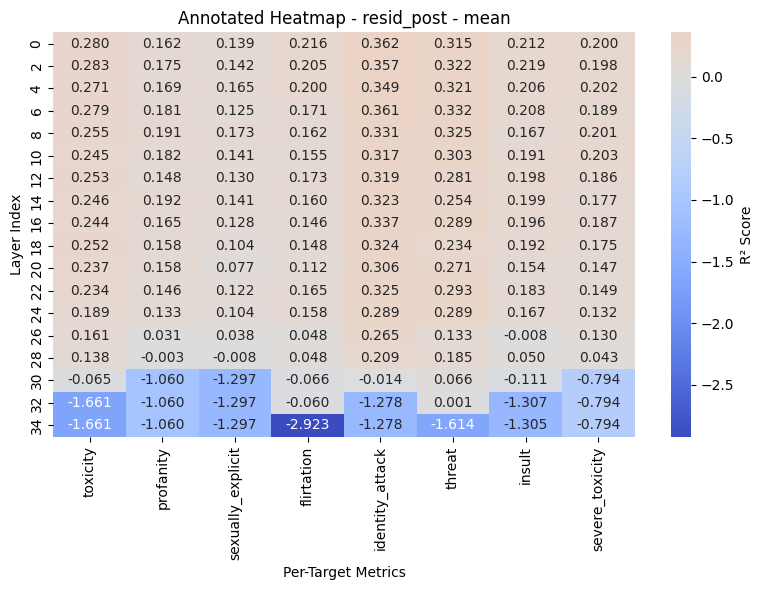

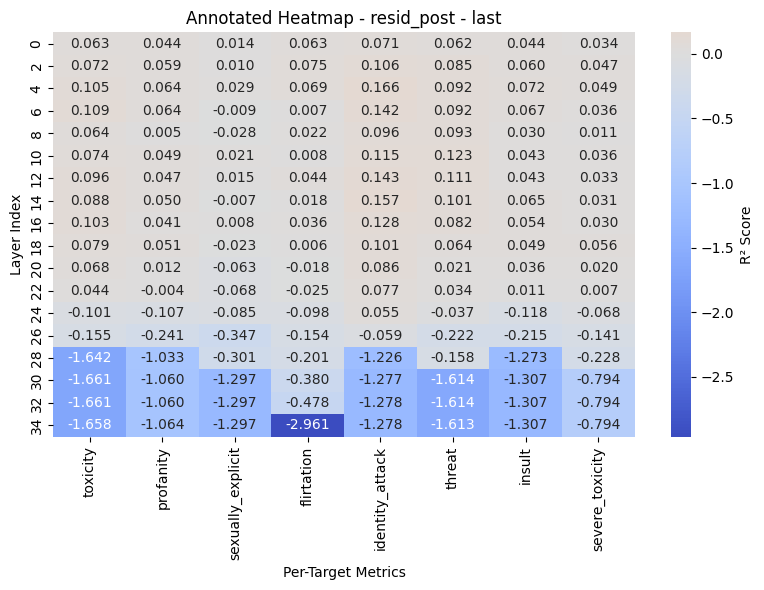

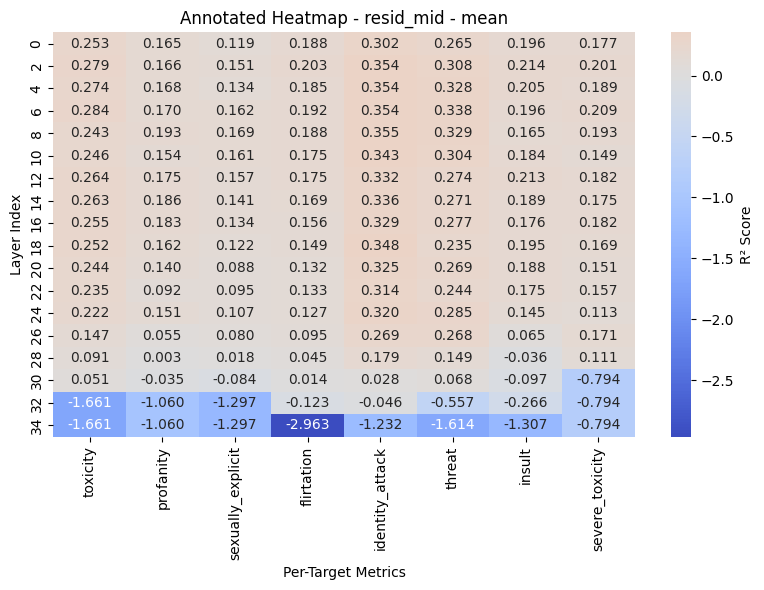

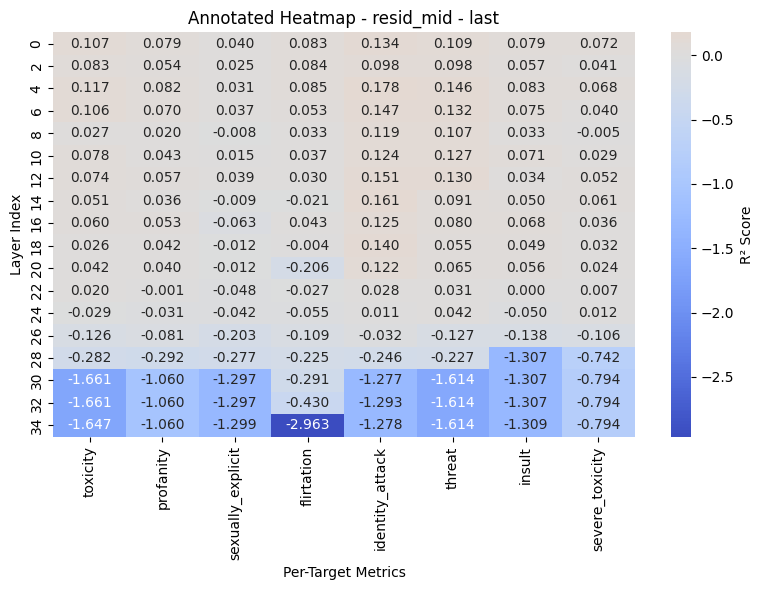

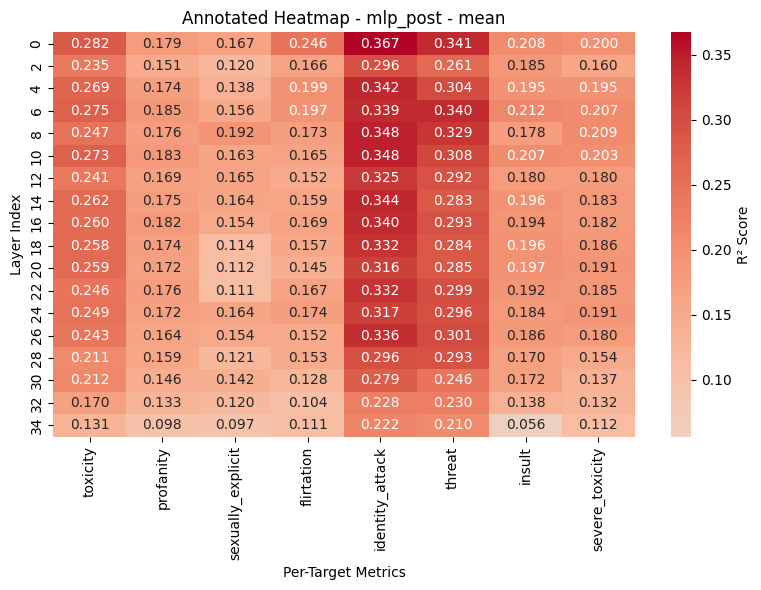

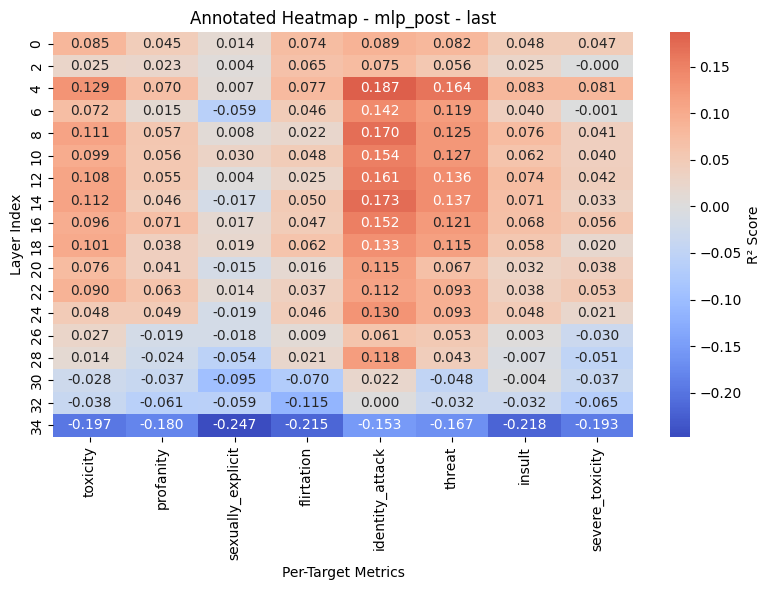

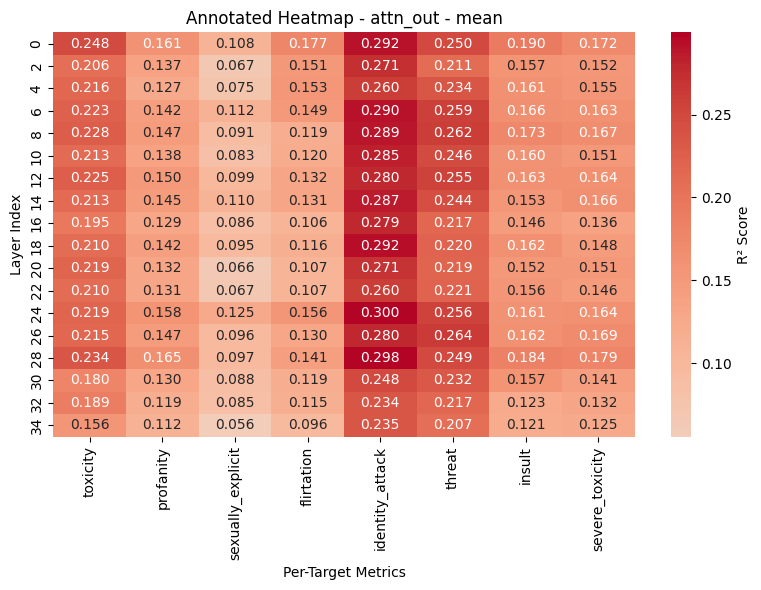

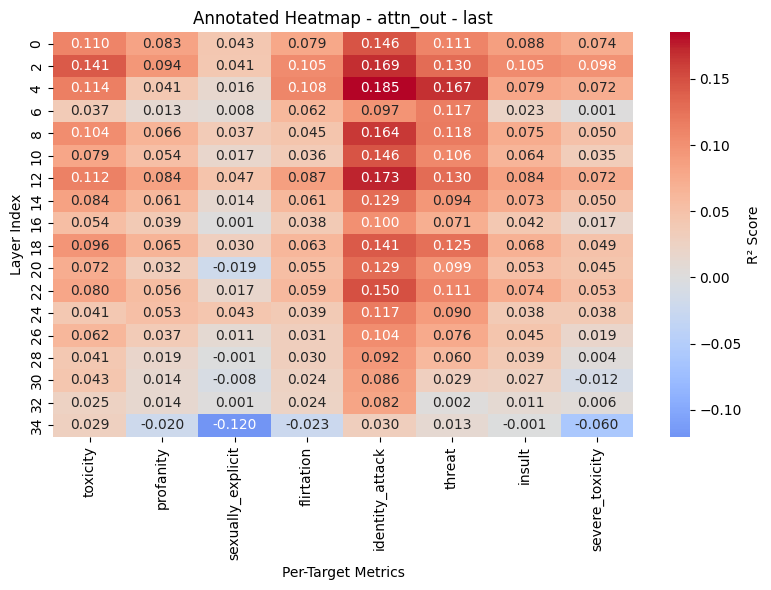

In [17]:
for act_type, agg_type in product(ACTIVATION_TYPES, AGG_FUNCS_ACTIVATIONS):

        subset = result_df[(result_df['act_type'] == act_type) & (result_df['agg_type'] == agg_type)].set_index('layer_idx')
        metric_cols = [c for c in result_df.columns if not c in ('act_type', 'layer_idx', 'agg_type')]
        heatmap_data = subset[metric_cols]
        heatmap_data.columns = TARGETS
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='coolwarm', 
                    center=0, cbar_kws={'label': 'R² Score'})
        plt.title(f'Annotated Heatmap - {act_type} - {agg_type}')
        plt.ylabel('Layer Index')
        plt.xlabel('Per-Target Metrics')
        plt.tight_layout()
        plt.show()


In [23]:
index = result_df[[c for c in result_df.columns if 'target' not in c]]
scores = np.sum(result_df[[c for c in result_df.columns if 'target' in c]].values, axis=-1)
index['agg_target'] = scores
index.set_index(['layer_idx', 'act_type', 'agg_type'], inplace=True)
index.sort_values('agg_target', ascending=False, inplace=True)

/tmp/ipykernel_14029/1054082536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index['agg_target'] = scores
/tmp/ipykernel_14029/1054082536.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index.sort_values('agg_target', ascending=False, inplace=True)


In [25]:
index.head(10)

agg_target
layer_idx act_type   agg_type            
0         mlp_post   mean        1.990074
6         mlp_post   mean        1.910417
          resid_mid  mean        1.904899
2         resid_post mean        1.900311
0         resid_post mean        1.886918
4         resid_post mean        1.883359
2         resid_mid  mean        1.874961
8         mlp_post   mean        1.851814
10        mlp_post   mean        1.849537
6         resid_post mean        1.845835

#### Create WDMP Embeddings

In [37]:
# save_activations(texts, labels)

In [33]:
def gather_full_tensor_wdmp( act_type, layer_idx, split='all', agg_type='last', dir=None):
    dir = dir or SAVE_DIR
    files = sorted([
            f for f in os.listdir(f"{dir}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt") and agg_type in f
     ])
    activations = []
    texts = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        texts.append(f['labels'])        
        activations.append(f['activations'])
        
    activations = torch.cat(
        activations, dim=0
    )
    texts = [t[-1] for t in texts]
    return activations, texts



In [34]:
n_targets = 8

In [35]:
from functools import partial, cache
from utils import LinearProbe

# ====================== DATA PREPARATION ======================
@cache
def load_probe_data_cached_rgr(act_type, layer_idx, agg_type, probe_dir, act_dir):
    """Cached data loading"""

    
    probe_path = f'{probe_dir}/regression_probe_l{layer_idx}_{act_type}_{agg_type}.pt'
    full_dataset = ActivationDataset(act_type, layer_idx, 'all', gathering_func=partial(gather_full_tensor_wdmp, dir=act_dir), agg_type=agg_type)
    
    probe_state = torch.load(probe_path)
    probe = LinearProbe(full_dataset.data.size(-1), n_targets, sigmoid=SIGMOID_PROBE)
    probe.load_state_dict(probe_state)
    probe.eval()
    
    with torch.no_grad():
        outputs = probe(full_dataset.data.to(torch.float32)).cpu().numpy()
        
        # Option 2: Per-target centering (across questions for each target)
        # Shape: (n_questions, n_targets)
        mean = np.mean(outputs, axis=0, keepdims=True)  # (1, n_targets)
        std = np.std(outputs, axis=0, keepdims=True)    # (1, n_targets)
        
        # Avoid division by zero
        std = np.where(std < 1e-8, 1.0, std)
        
        outputs = (outputs - mean) / std

    
    
    result = {
        'outputs': outputs,  # Shape: (n_questions, n_targets)
        'probe_weight': probe.linear.weight.detach().numpy(),
        'labels': full_dataset.labels,
        'activations': full_dataset.data,
        'n_samples': len(full_dataset.labels)
    }
    
    return result

In [36]:
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dynamics(act_type, agg_type, probe_dir, act_dir, sigmoid=True,):
    indices = LAYERS
    all_norms = []
    
    # Collect norms for each layer
    for index in indices: 
        probe_data = load_probe_data_cached_rgr(act_type, index, agg_type, probe_dir, act_dir)['outputs']
        if sigmoid:
            probe_data = np_sigmoid(probe_data)

        norms = np.linalg.norm(probe_data, axis=-1)  # shape: (n_samples,)
        all_norms.append(norms)
    
    # Stack into shape: (n_layers, n_samples)
    all_norms = np.stack(all_norms, axis=0)
    
    # Option 1: Plot all samples with low alpha for density
    plt.figure(figsize=(12, 6))
    for i in range(all_norms.shape[1]):  # iterate over samples
        plt.plot(LAYERS, all_norms[:, i], alpha=0.3, color='blue', linewidth=0.5)
    
    plt.xlabel('Layer Progression')
    plt.ylabel('Norm of Activations')
    plt.title(f'By-Sample Norm Dynamics - {act_type} ({agg_type})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Option 2: Show statistics with individual samples
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: All samples with mean overlay
    for i in range(all_norms.shape[1]):
        ax1.plot(LAYERS, all_norms[:, i], alpha=0.2, color='blue', linewidth=0.5)
    
    mean_norms = np.mean(all_norms, axis=1)
    std_norms = np.std(all_norms, axis=1)
    ax1.plot(LAYERS, mean_norms, 'r-', linewidth=2, label='Mean')
    ax1.fill_between(LAYERS, mean_norms - std_norms, mean_norms + std_norms, 
                      alpha=0.2, color='red', label='±1 std')
    ax1.set_xlabel('Layer Progression')
    ax1.set_ylabel('Norm')
    ax1.set_title('All Samples with Statistics')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right: Heatmap of norms across samples and layers
    im = ax2.imshow(all_norms.T, aspect='auto', cmap='viridis', 
                    extent=[0, len(LAYERS)-1, 0, all_norms.shape[1]], 
                    origin='lower')
    ax2.set_xlabel('Layer Progression')
    ax2.set_ylabel('Sample Index')
    ax2.set_title('Norm Heatmap')

    # Set x-tick labels to show actual layer percentages
    ax2.set_xticks(range(len(LAYERS)))
    ax2.set_xticklabels([f'{p:.2f}' for p in LAYERS], rotation=45)

    plt.colorbar(im, ax=ax2, label='Norm')
    
    plt.tight_layout()
    plt.show()
    
    # Option 3: Box plot per layer (good for distribution)
    plt.figure(figsize=(12, 6))
    plt.boxplot(all_norms.T, positions=LAYERS, widths=0.02)
    plt.xlabel('Layer Progression')
    plt.ylabel('Norm')
    plt.title(f'Norm Distributions per Layer - {act_type} ({agg_type})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return all_norms


from utils import ActivationDataset

In [41]:
SIGMOID_PROBE = True

In [42]:
plot_dynamics('resid_mid', 'last', 'real-toxicity-prompts', 'wmdp-bio')

FileNotFoundError: [Errno 2] No such file or directory: 'wmdp-bio/resid_mid_layer0.0_all'

In [85]:
from ipywidgets import interact, fixed
import ipywidgets as widgets

DATASETS = ['wmdp-bio', 'wmdp', 'TDC23', 'dolly']

@interact(
    act_type=widgets.Dropdown(options=ACTIVATION_TYPES, description='Act Type:'),
    agg_type=widgets.Dropdown(options=AGG_FUNCS_ACTIVATIONS.keys(), description='Agg Type:'),
    max_samples=widgets.IntSlider(value=50, min=10, max=200, step=10, description='Samples:'),
    act_dir=widgets.Dropdown(options=DATASETS, description='activations:'),
    show_heatmap=widgets.Checkbox(value=True, description='Heatmap'),
    normalize=widgets.Checkbox(value=False, description='Normalize'),
    norm_type=widgets.Dropdown(options=[1, 2, float('inf')], description='Norm Type:')
)
def interactive_plot(act_type, agg_type, act_dir, show_heatmap, norm_type, normalize, n_layers=36):
    """Interactive plotting function"""
    indices = LAYERS
    all_norms = []
    
    for index in indices: 
        probe_data = load_probe_data_cached_rgr(act_type, index, agg_type, act_dir=act_dir, probe_dir='real-toxicity-prompts/')
        norms = np.linalg.norm(probe_data['outputs'], axis=-1, ord=norm_type)
        all_norms.append(norms)
    
    all_norms = np.stack(all_norms, axis=0)
    
    # Apply normalization if selected
    if normalize:
        all_norms = all_norms / all_norms[0:1, :]
        ylabel = 'Relative Norm (normalized to layer 1)'
    else:
        ylabel = 'Norm'
    
    # # Subsample if needed
    # if max_samples < all_norms.shape[1]:
    #     # Random subsample
    #     idx = np.random.choice(all_norms.shape[1], max_samples, replace=False)
    #     all_norms = all_norms[:, idx]
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) if show_heatmap else plt.subplots(figsize=(10, 6))
    
    # Line plot
    for i in range(all_norms.shape[1]):
        ax1.plot(LAYERS, all_norms[:, i], alpha=0.2, color='blue', linewidth=0.5)
    
    mean_norms = np.mean(all_norms, axis=1)
    std_norms = np.std(all_norms, axis=1)
    ax1.plot(LAYERS, mean_norms, 'r-', linewidth=2, label='Mean')
    ax1.fill_between(LAYERS, mean_norms - std_norms, mean_norms + std_norms, 
                      alpha=0.2, color='red', label='±1 std')
    ax1.set_xlabel('Layer Progression')
    ax1.set_ylabel(ylabel)
    ax1.set_title(f'{act_type} ({agg_type}) - {all_norms.shape[1]} samples')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    if show_heatmap:
        im = ax2.imshow(all_norms.T, aspect='auto', cmap='viridis',
                        extent=[0, 1, 0, all_norms.shape[1]], 
                        origin='lower')
        ax2.set_xlabel('Layer Progression')
        ax2.set_ylabel('Sample Index')
        ax2.set_title(f'Heatmap ({all_norms.shape[1]} samples)')
        plt.colorbar(im, ax=ax2, label=ylabel)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Act Type:', options=('resid_post', 'resid_mid', 'mlp_post', 'attn_…

In [69]:
load_probe_data_cached_rgr(act_dir='wmdp-bio', probe_dir='real-toxicity-prompts', layer_idx=20, act_type='resid_post', agg_type='mean')

{'outputs': array([[ 1.7107514 ,  0.795915  ,  0.17058304, ...,  0.7568668 ,
          1.3069183 ,  0.5264829 ],
        [-1.0630815 , -0.68646204, -0.6707601 , ..., -0.47217655,
         -0.97845715, -0.5539928 ],
        [-0.5625486 , -0.2603647 , -0.06703683, ..., -0.0728011 ,
         -0.12619917, -0.29453033],
        ...,
        [ 1.022975  ,  0.1072429 ,  0.2592154 , ...,  1.7961513 ,
          0.6660626 ,  1.2500573 ],
        [-0.478896  , -0.2001522 , -0.49827868, ..., -0.7031547 ,
         -0.02234089, -0.25025275],
        [-0.829049  , -1.104542  , -1.1392431 , ..., -0.90455574,
         -0.9729238 , -0.95067114]], dtype=float32),
 'probe_weight': array([[-0.007761  ,  0.01454219,  0.00701437, ..., -0.00831054,
         -0.01770403,  0.00940545],
        [-0.01510026,  0.01442059,  0.00375141, ...,  0.00235988,
          0.00711604, -0.03115067],
        [-0.01464457,  0.01100155,  0.00210378, ..., -0.00170739,
          0.00234056, -0.02888116],
        ...,
        [-0.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from collections import Counter

# Define your available options - these should be defined elsewhere or passed as parameters
# ACT_TYPES = ACTIVATION_TYPES
# AGG_TYPES = list(AGG_FUNCS_ACTIVATIONS)
# N_LAYERS = ... 
# LAYERS = [...]

# If not defined elsewhere, define placeholder values

def estimate_norm_distributions(act_type, agg_type, act_dir, n_layers=N_LAYERS):
    """Estimate norm distributions per layer and return statistics"""
    indices = LAYERS
    
    layer_data = {}
    all_norms = []
    
    for idx, layer_idx in enumerate(indices):
        # Assuming load_probe_data_cached_rgr is defined elsewhere
        probe_data = load_probe_data_cached_rgr(act_type, layer_idx, agg_type, probe_dir='real-toxicity-prompts', act_dir=act_dir)
        norms = np.linalg.norm(probe_data['outputs'], axis=-1)
        
        # Calculate statistics
        q1 = np.percentile(norms, 25)
        q3 = np.percentile(norms, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Identify outliers for this layer
        outliers = (norms < lower_bound) | (norms > upper_bound)
        
        layer_data[LAYERS[idx]] = {
            'norms': norms,
            'mean': np.mean(norms),
            'median': np.median(norms),
            'std': np.std(norms),
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outliers': outliers,
            'n_outliers': np.sum(outliers),
            'outlier_indices': np.where(outliers)[0],
            'layer_idx': layer_idx
        }
        
        all_norms.append(norms)
    
    all_norms = np.stack(all_norms, axis=0)  # shape: (n_layers, n_samples)
    
    return layer_data, all_norms

def plot_distributions_with_outliers(act_type, agg_type, act_dir, show_outliers=True, 
                                     plot_type='boxen', sample_subset=None):
    """Plot distributions with outliers highlighted"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type, act_dir)
    
    # # Subsample if needed (for visualization)
    if False:
        idx = np.random.choice(all_norms.shape[1], sample_subset, replace=False)
        all_norms_subset = all_norms[:, idx]
    else:
        all_norms_subset = all_norms
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Distribution plot (boxen or violin)
    layer_labels = [f'{p:.0%}' for p in LAYERS]
    
    if plot_type == 'boxen':
        sns.boxenplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Boxen Plot of Norms per Layer')
    elif plot_type == 'violin':
        sns.violinplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Violin Plot of Norms per Layer')
    else:
        sns.boxplot(data=all_norms_subset.T, ax=axes[0])
        axes[0].set_title('Box Plot of Norms per Layer')
    
    axes[0].set_xlabel('Layer Progression')
    axes[0].set_ylabel('Norm')
    axes[0].set_xticklabels(layer_labels, rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # 2. IQR bounds and outliers per layer
    layer_positions = range(len(LAYERS))
    
    # First, collect all data points to set proper y-limits
    all_norms_for_plot = []
    for i, pos in enumerate(layer_positions):
        layer_pct = LAYERS[i]
        data = layer_data[layer_pct]
        all_norms_for_plot.extend(data['norms'])
    
    # Set y-limits with some padding
    y_min = min(all_norms_for_plot) - 0.1 * (max(all_norms_for_plot) - min(all_norms_for_plot))
    y_max = max(all_norms_for_plot) + 0.1 * (max(all_norms_for_plot) - min(all_norms_for_plot))
    axes[1].set_ylim(y_min, y_max)
    
    # Now plot the IQR ranges and outliers
    for i, pos in enumerate(layer_positions):
        layer_pct = LAYERS[i]
        data = layer_data[layer_pct]
        
        # Normalize data values to [0,1] range based on y-limits
        def normalize(val):
            return (val - y_min) / (y_max - y_min)
        
        q1_norm = normalize(data['q1'])
        q3_norm = normalize(data['q3'])
        median_norm = normalize(data['median'])
        
        # Plot IQR range
        axes[1].axvspan(pos - 0.2, pos + 0.2, 
                        alpha=0.3, color='blue', 
                        ymin=q1_norm, ymax=q3_norm)
        
        # Plot median line
        axes[1].axvline(pos, color='red', alpha=0.7, 
                        ymin=median_norm - 0.01, ymax=median_norm + 0.01, 
                        linewidth=2)
        
        # Plot outliers
        if show_outliers:
            outlier_norms = data['norms'][data['outliers']]
            if len(outlier_norms) > 0:
                # Jitter for visibility
                x_jitter = np.random.normal(pos, 0.05, len(outlier_norms))
                axes[1].scatter(x_jitter, outlier_norms, 
                              alpha=0.6, color='red', s=15, zorder=5)
        
        # Also plot the non-outliers as small points for context
        non_outlier_norms = data['norms'][~data['outliers']]
        if len(non_outlier_norms) > 0 and len(non_outlier_norms) < 1000:  # Limit for performance
            x_jitter = np.random.normal(pos, 0.05, len(non_outlier_norms))
            axes[1].scatter(x_jitter, non_outlier_norms, 
                          alpha=0.1, color='blue', s=5)
    
    axes[1].set_xlabel('Layer Progression')
    axes[1].set_ylabel('Norm')
    axes[1].set_title('IQR Bounds and Outliers')
    axes[1].set_xticks(layer_positions)
    axes[1].set_xticklabels(layer_labels, rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Number of outliers per layer
    n_outliers = [layer_data[p]['n_outliers'] for p in LAYERS]
    axes[2].bar(layer_labels, n_outliers, color='red', alpha=0.7)
    axes[2].set_xlabel('Layer Progression')
    axes[2].set_ylabel('Number of Outliers')
    axes[2].set_title(f'Total Outliers per Layer (IQR method)')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for i, v in enumerate(n_outliers):
        axes[2].text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return layer_data

def extract_outlier_indices(layer_data, method='union', threshold_percentile=None):
    """
    Extract indices of questions that are outliers
    
    Args:
        layer_data: Output from estimate_norm_distributions
        method: 'union' (outlier in any layer), 'intersection' (outlier in all layers),
                'majority' (outlier in >50% of layers)
        threshold_percentile: Optional tuple (lower_percentile, upper_percentile) 
                              to define outliers using percentiles instead of IQR.
                              Applied to each layer independently.
    
    Returns:
        Dictionary with outlier indices and metadata
    """
    all_outlier_indices = []
    
    for p in LAYERS:
        data = layer_data[p]
        
        if threshold_percentile is not None:
            # Use custom percentile threshold instead of IQR
            lower = np.percentile(data['norms'], threshold_percentile[0])
            upper = np.percentile(data['norms'], threshold_percentile[1])
            outliers = (data['norms'] < lower) | (data['norms'] > upper)
            outlier_indices = np.where(outliers)[0]
        else:
            # Use the pre-computed outlier indices from the data
            outlier_indices = data['outlier_indices']
        
        all_outlier_indices.append(set(outlier_indices))
    
    # Combine based on method
    if method == 'union':
        final_indices = set().union(*all_outlier_indices)
    elif method == 'intersection':
        final_indices = set.intersection(*all_outlier_indices)
    elif method == 'majority':
        # Count occurrences across layers
        all_indices = []
        for s in all_outlier_indices:
            all_indices.extend(list(s))
        counter = Counter(all_indices)
        n_layers = len(LAYERS)
        final_indices = {idx for idx, count in counter.items() 
                        if count > n_layers / 2}
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Get detailed information about each outlier
    outlier_details = {}
    for idx in final_indices:
        layers_outlier = []
        for i, p in enumerate(LAYERS):
            if idx in all_outlier_indices[i]:
                layers_outlier.append(p)
        outlier_details[idx] = {
            'layers': layers_outlier,
            'n_layers_outlier': len(layers_outlier)
        }
    
    return {
        'indices': sorted(list(final_indices)),
        'details': outlier_details,
        'n_outliers': len(final_indices),
        'method': method,
        'all_outlier_sets': all_outlier_indices
    }

def get_questions_for_indices(indices, dataset):
    """Retrieve questions (labels) for given indices"""
    # Fix: Use probe_dir instead of probe_data parameter

    questions = [dataset[i] for i in indices]

    # probe_data = load_probe_data_cached_rgr(act_type, layer_idx, agg_type, probe_dir='real-toxicity-prompts', act_dir=act_dir)
    # labels = probe_data.get('labels', [])
    
    # # If labels is a list of lists, flatten or handle appropriately
    # if isinstance(labels, list) and len(labels) > 0:
    #     if isinstance(labels[0], list):
    #         # If each label is a list, join them
    #         questions = [' '.join(l) for l in labels]
    #     else:
    #         questions = labels
    # else:
    #     questions = [f"Question_{i}" for i in range(len(indices))]
    
    # Return questions for the specified indices
    return [questions[i] for i in indices if i < len(questions)]

def create_outlier_question_list(outlier_indices, dataset, max_display=100):
    """Create a scrollable HTML list of outlier questions"""
    # Fix: Pass act_dir parameter correctly
    questions = get_questions_for_indices(outlier_indices, dataset)
    
    if len(questions) == 0:
        return HTML("<p><i>No outliers found</i></p>")
    
    # Limit display if too many
    display_count = min(len(questions), max_display)
    display_indices = outlier_indices[:display_count]
    display_questions = questions[:display_count]
    
    # Create HTML with scrollable container and text wrapping
    html = f"""
    <div style="border: 1px solid #ccc; border-radius: 5px; padding: 10px; 
                max-height: 400px; overflow-y: auto; overflow-x: hidden;
                background: #f9f9f9; font-family: monospace; font-size: 12px;">
        <div style="position: sticky; top: 0; background: #f9f9f9; padding-bottom: 8px; 
                    border-bottom: 2px solid #ddd; margin-bottom: 8px; z-index: 1;">
            <strong>Outlier Questions ({len(questions)} total)</strong>
            <span style="float: right; color: #666; font-size: 11px;">
                Scroll to view all ▼
            </span>
        </div>
        <ul style="list-style-type: none; padding-left: 0; margin: 0; 
                   word-wrap: break-word; white-space: pre-wrap; 
                   word-break: break-word; max-width: 100%;">
    """
    
    for idx, q in zip(display_indices, display_questions):
        # Handle case where q might be a dictionary or other non-string type
        if isinstance(q, dict):
            # Try to extract text from common dictionary keys
            if 'text' in q:
                q_str = q['text']
            elif 'question' in q:
                q_str = q['question']
            elif 'label' in q:
                q_str = q['label']
            elif 'content' in q:
                q_str = q['content']
            else:
                # If no recognizable key, convert to string
                q_str = str(q)
        elif isinstance(q, list):
            # If it's a list, join elements with space
            q_str = ' '.join(str(item) for item in q)
        else:
            # Assume it's a string or convertible to string
            q_str = str(q)
        
        # Truncate long questions but keep readable
        if len(q_str) > 200:
            q_display = q_str[:200] + "..."
        else:
            q_display = q_str
        
        # Escape HTML special characters to prevent rendering issues
        q_display = q_display.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        
        html += f"""
        <li style="padding: 6px 4px; border-bottom: 1px solid #eee; 
                   display: flex; align-items: flex-start; gap: 8px;">
            <span style="font-weight: bold; color: #666; min-width: 40px; 
                         font-size: 11px; flex-shrink: 0;">
                [{idx}]
            </span> 
            <span style="flex: 1; word-wrap: break-word; overflow-wrap: break-word; 
                         white-space: pre-wrap; word-break: break-word; 
                         max-width: 100%;">
                {q_display}
            </span>
        </li>
        """
    
    if len(questions) > max_display:
        html += f"""
        <li style="padding: 6px 4px; color: #999; font-style: italic; 
                   text-align: center; border-top: 2px dashed #ddd; margin-top: 4px;">
            ... and {len(questions) - max_display} more questions
        </li>
        """
    
    html += """
        </ul>
        <div style="position: sticky; bottom: 0; background: #f9f9f9; 
                    padding-top: 8px; border-top: 1px solid #ddd; 
                    margin-top: 8px; text-align: center; color: #666; font-size: 11px;">
            <span>↑ Scroll up to see more ↑</span>
        </div>
    </div>
    """
    
    return HTML(html)

def interactive_outlier_analysis(act_dir, dataset):
    """Interactive widget to explore outliers with act_type and agg_type selection"""
    ACT_TYPES = ACTIVATION_TYPES 
    AGG_TYPES = list(AGG_FUNCS_ACTIVATIONS)
    # Create act_type and agg_type dropdowns
    act_type_dropdown = widgets.Dropdown(
        options=ACT_TYPES,
        value=ACT_TYPES[0] if ACT_TYPES else None,
        description='Act Type:',
        style={'description_width': 'initial'}
    )
    
    agg_type_dropdown = widgets.Dropdown(
        options=AGG_TYPES,
        value=AGG_TYPES[0] if AGG_TYPES else None,
        description='Agg Type:',
        style={'description_width': 'initial'}
    )
    
    method_dropdown = widgets.Dropdown(
        options=['union', 'intersection', 'majority'],
        value='union',
        description='Method:'
    )
    
    plot_type_dropdown = widgets.Dropdown(
        options=['boxen', 'violin', 'box'],
        value='boxen',
        description='Plot Type:'
    )
    
    sample_slider = widgets.IntSlider(
        value=100,
        min=10,
        max=500,
        step=10,
        description='Max Samples:'
    )
    
    show_outliers_checkbox = widgets.Checkbox(
        value=True,
        description='Show Outliers'
    )
    
    # Add a slider for max questions to display
    max_questions_slider = widgets.IntSlider(
        value=50,
        min=10,
        max=200,
        step=10,
        description='Max Questions:',
        style={'description_width': 'initial'}
    )
    
    # Output areas
    plot_output = widgets.Output()
    summary_output = widgets.Output()
    questions_output = widgets.Output()
    
    def update_analysis(change=None):
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        
        if act_type is None or agg_type is None:
            return
        
        with plot_output:
            clear_output(wait=True)
            # Fix: Pass act_dir parameter
            layer_data = plot_distributions_with_outliers(
                act_type, agg_type, 
                act_dir=act_dir,  # Replace with actual act_dir value
                show_outliers=show_outliers_checkbox.value,
                plot_type=plot_type_dropdown.value,
                sample_subset=sample_slider.value
            )
        
        # Extract outliers and update summary and question list
        with summary_output:
            clear_output(wait=True)
            
            # Fix: Pass act_dir parameter
            layer_data, all_norms = estimate_norm_distributions(act_type, agg_type, act_dir=act_dir)
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            # Print summary in a scrollable text area
            summary_text = []
            summary_text.append(f"{'='*60}")
            summary_text.append(f"OUTLIER SUMMARY - {act_type} ({agg_type})")
            summary_text.append(f"{'='*60}")
            summary_text.append(f"Method: {method_dropdown.value}")
            summary_text.append(f"Total samples: {all_norms.shape[1]}")
            summary_text.append(f"Outlier samples: {outlier_result['n_outliers']}")
            summary_text.append(f"Outlier percentage: {100 * outlier_result['n_outliers'] / all_norms.shape[1]:.2f}%")
            summary_text.append(f"\nOutlier indices: {outlier_result['indices'][:20]}{'...' if len(outlier_result['indices']) > 20 else ''}")
            
            # Show distribution of how many layers each outlier appears in
            if outlier_result['n_outliers'] > 0:
                layer_counts = [outlier_result['details'][idx]['n_layers_outlier'] 
                              for idx in outlier_result['indices']]
                summary_text.append(f"\nOutliers by number of layers affected:")
                for i in range(1, len(LAYERS) + 1):
                    count = sum(1 for c in layer_counts if c == i)
                    summary_text.append(f"  {i} layer(s): {count} samples")
            
            summary_text.append(f"{'='*60}")
            
            # Display in scrollable text area
            display(HTML(f"""
            <div style="border: 1px solid #ccc; border-radius: 5px; padding: 10px; 
                        max-height: 300px; overflow-y: auto; 
                        background: #f5f5f5; font-family: monospace; font-size: 12px;
                        white-space: pre-wrap; word-wrap: break-word;">
                {chr(10).join(summary_text)}
            </div>
            """))
        
        # Update questions list
        with questions_output:
            clear_output(wait=True)
            
            # Re-extract outlier indices for questions
            outlier_result = extract_outlier_indices(
                layer_data, 
                method=method_dropdown.value
            )
            
            if outlier_result['n_outliers'] > 0:
                # Fix: Pass act_dir parameter and proper layer_idx
                display(create_outlier_question_list(
                    outlier_result['indices'], 
                    dataset=dataset,
                    max_display=max_questions_slider.value
                ))
            else:
                display(HTML("<p><i>No outliers found</i></p>"))
    
    # Link widgets
    act_type_dropdown.observe(update_analysis, 'value')
    agg_type_dropdown.observe(update_analysis, 'value')
    method_dropdown.observe(update_analysis, 'value')
    plot_type_dropdown.observe(update_analysis, 'value')
    sample_slider.observe(update_analysis, 'value')
    show_outliers_checkbox.observe(update_analysis, 'value')
    max_questions_slider.observe(update_analysis, 'value')
    
    # Create layout with scrollable containers
    ui = widgets.VBox([
        widgets.HBox([act_type_dropdown, agg_type_dropdown]),
        widgets.HBox([method_dropdown, plot_type_dropdown]),
        widgets.HBox([sample_slider, show_outliers_checkbox, max_questions_slider]),
        plot_output,
        widgets.HBox([
            widgets.VBox([
                widgets.Label("Summary", layout=widgets.Layout(width='100%')),
                summary_output
            ], layout=widgets.Layout(width='40%', overflow='auto')),
            widgets.VBox([
                widgets.Label("Outlier Questions", layout=widgets.Layout(width='100%')),
                questions_output
            ], layout=widgets.Layout(width='60%', overflow='auto'))
        ], layout=widgets.Layout(width='100%'))
    ], layout=widgets.Layout(width='100%'))
    
    display(ui)
    
    # Initial update
    update_analysis()
    
    # Return function to get current data
    def get_current_outliers():
        act_type = act_type_dropdown.value
        agg_type = agg_type_dropdown.value
        if act_type is None or agg_type is None:
            return None
        layer_data, _ = estimate_norm_distributions(act_type, agg_type, act_dir)
        return extract_outlier_indices(layer_data, method=method_dropdown.value)
    
    return get_current_outliers

def analyze_outliers(act_type, agg_type, act_dir, method='union'):
    """Main function to run outlier analysis"""
    layer_data, all_norms = estimate_norm_distributions(act_type, agg_type, act_dir)
    
    # Plot distributions
    plot_distributions_with_outliers(act_type, agg_type, act_dir)
    
    # Extract outliers using different methods
    for method in ['union', 'intersection', 'majority']:
        outlier_result = extract_outlier_indices(layer_data, method=method)
        print(f"\n{method.upper()}: {outlier_result['n_outliers']} outliers")
        if outlier_result['n_outliers'] < 20:
            print(f"  Indices: {outlier_result['indices']}")
    
    # Show questions for union outliers
    outlier_result = extract_outlier_indices(layer_data, method='union')
    if outlier_result['n_outliers'] > 0:
        print("\n" + "="*60)
        print("OUTLIER QUESTIONS (union method)")
        print("="*60)
        display(create_outlier_question_list(
            outlier_result['indices'], 
            act_type, 
            agg_type,
            act_dir=act_dir,
            layer_idx=0,
            max_display=50
        ))
    
    return layer_data

# Run the interactive version
# outlier_getter = interactive_outlier_analysis()

# Or run with specific parameters
# analyze_outliers('resid_post', 'mean')

In [71]:
from consts import *

In [73]:
from datasets import load_dataset


def get_wmdp_subset_questions(subset):
    ds = load_dataset("cais/wmdp", f"{subset}")['test']
    texts = [i['question'] for i in ds] 
    return texts



In [74]:
# Interactive version with all widgets

subset = 'wmdp-bio'
questions = get_wmdp_subset_questions(subset)
outlier_getter = interactive_outlier_analysis(subset, questions)

# Or one-shot analysis
# analyze_outliers('resid_post', 'mean')

In [ ]:
# Run interactive analysis
# layer_data = interactive_outlier_analysis('resid_post', 'mean')

In [101]:
def get_k_ids(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20):
    scores = load_probe_data_cached_rgr(act_dir=act_dir, layer_idx=layer_idx, act_type=act_type, agg_type=agg_type, probe_dir='real-toxicity-prompts')['outputs']
    if use_sigmoid:
        scores = 1 / (1 + np.exp(-scores))
    norms = np.linalg.norm(scores, axis=-1, ord=norm_type)
    sorted_idx = np.argsort(norms) 
    topk = sorted_idx[-k:]
    lastk = sorted_idx[:k]
    return topk, lastk

def get_k_questions(questions, act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20):
    topk, lastk = get_k_ids(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20)
    topk_q = [questions[i] for i in topk]
    lastk_q = [questions[i] for i in lastk]
    df = pd.DataFrame({'Top Indices': topk, 'Top Questions': topk_q, 'Last Indices': lastk, 'Last Questions': lastk_q})
    return df 

get_k_questions(get_wmdp_subset_questions('wmdp-bio'), 'wmdp-bio', 18, 'mlp_post', 'mean', 1,)


,Top Indices,Top Questions,Last Indices,Last Questions
0,143,What is the role of the assembly-activating pr...,73,Which activities have been found in lymphostat...
1,770,How does variation in relative humidity (RH) i...,689,The HSV-1 protein ICP34.5 is known to countera...
2,857,In the context of reverse genetics for RNA vir...,558,How does the timing of exposure to HD5 relativ...
3,49,What is a concern that has arisen from the bio...,334,Which of the following corn diseases is liable...
4,972,Why is it important to include a self-inactiva...,384,How might the ability to customize gene synthe...
5,722,"In herpesvirus latency, which cellular compart...",136,A hypothesis for the different pathology of fl...
6,984,What is the result of the cellular RNA-interfe...,175,What parts of the human body can the H5HA-muta...
7,840,What is the significance of identifying the pr...,170,What steps should be taken to produce viral pr...
8,736,Which of the following herpesvirus proteins is...,607,What is the primary advantage of using phage d...
9,88,Which bioweapons agent did Japan use in World ...,677,What is the primary role of the herpes simplex...


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

def get_k_ids(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20):
    scores = load_probe_data_cached_rgr(act_dir=act_dir, layer_idx=layer_idx, act_type=act_type, agg_type=agg_type, probe_dir='real-toxicity-prompts')['outputs']
    if use_sigmoid:
        scores = 1 / (1 + np.exp(-scores))
    norms = np.linalg.norm(scores, axis=-1, ord=norm_type)
    sorted_idx = np.argsort(norms) 
    topk = sorted_idx[-k:][::-1]
    lastk = sorted_idx[:k]
    return topk, lastk

def get_k_questions(questions, act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20):
    topk, lastk = get_k_ids(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid, k)
    topk_q = [questions[i] for i in topk]
    lastk_q = [questions[i] for i in lastk]
    df = pd.DataFrame({'Top Indices': topk, 'Top Questions': topk_q, 'Last Indices': lastk, 'Last Questions': lastk_q})
    return df

# Create interactive widget
def display_scrollable_df(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid=True, k=20):
    # Get the dataframe
    questions = get_wmdp_subset_questions(act_dir)
    df = get_k_questions(questions, act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid, k)
    
    # Create scrollable HTML with styling
    html = df.to_html(escape=False, index=False)
    styled_html = f"""
    <style>
        .scrollable-table {{
            max-height: 500px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }}
        .scrollable-table table {{
            border-collapse: collapse;
            width: 100%;
        }}
        .scrollable-table th {{
            background-color: #f2f2f2;
            position: sticky;
            top: 0;
            z-index: 10;
        }}
        .scrollable-table td, .scrollable-table th {{
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }}
        .scrollable-table tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        .scrollable-table tr:hover {{
            background-color: #f5f5f5;
        }}
    </style>
    <div class="scrollable-table">
        {html}
    </div>
    """
    return HTML(styled_html)

# Create interactive widget with controls
@widgets.interact(
    act_dir=['wmdp-bio', 'wmdp-chem', 'wmdp-cyber', 'dolly', 'TDC23'],  # Add your options
    layer_idx=widgets.IntSlider(min=LAYERS[0], max=LAYERS[-1], step=LAYERS[1] - LAYERS[0], value=18),
    act_type=ACTIVATION_TYPES,  # Add your options
    agg_type=list(AGG_FUNCS_ACTIVATIONS),  # Add your options
    norm_type=widgets.Dropdown(options=[1, 2, np.inf], value=1, description='Norm type:'),
    use_sigmoid=widgets.Checkbox(value=True, description='Use sigmoid'),
    k=widgets.IntSlider(min=5, max=50, step=5, value=20, description='k:')
)
def interactive_df(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid, k):
    return display_scrollable_df(act_dir, layer_idx, act_type, agg_type, norm_type, use_sigmoid, k)

interactive(children=(Dropdown(description='act_dir', options=('wmdp-bio', 'wmdp-chem', 'wmdp-cyber', 'dolly',…

Scrrollable questions 

### Clssification Setup

In [ ]:
EPOCHS = 200

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_probe_metrics(df, save_path=None):
    """
    Plot metrics from linear probe experiments.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', 'acc', 'auc', 'f1', 'recall', 'precision'
    save_path : str, optional
        Path to save the figure. If None, displays the plot.
    """
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Linear Probe Performance Metrics by Layer and Activation Type', fontsize=16, fontweight='bold')
    
    # Metrics to plot
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    titles = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Recall', 'Precision']
    
    # Get unique activation types
    act_types = df['act_type'].unique()
    
    # Define colors for different activation types
    colors = plt.cm.Set2(np.linspace(0, 1, len(act_types)))
    
    # Plot each metric
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 3, idx % 3]
        
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            ax.plot(subset['layer_idx'], subset[metric], 
                   marker='o', linewidth=2, markersize=6, 
                   label=act_type, color=color)
            ax.fill_between(subset['layer_idx'], subset[metric], alpha=0.1, color=color)
        
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel(metric.upper(), fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Set y-axis limits with padding
        y_min = df[metric].min() - 0.05
        y_max = df[metric].max() + 0.05
        ax.set_ylim([max(0, y_min), min(1, y_max)])
    
    # Bottom subplot for training loss (if available)
    ax = axes[1, 2]
    if 'final_tr_loss' in df.columns and df['final_tr_loss'].notna().any():
        for act_type, color in zip(act_types, colors):
            subset = df[df['act_type'] == act_type].sort_values('layer_idx')
            if subset['final_tr_loss'].notna().any():
                ax.plot(subset['layer_idx'], subset['final_tr_loss'], 
                       marker='s', linewidth=2, markersize=6, 
                       label=act_type, color=color)
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel('Training Loss', fontsize=12)
        ax.set_title('Final Training Loss', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    else:
        # Create a bar plot comparing act_types across metrics
        ax.axis('off')
        ax.text(0.5, 0.5, 'No training loss data available', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    else:
        plt.show()
    
    return fig


def plot_metric_heatmap(df, save_path=None):
    """
    Create a heatmap of metrics across layers and activation types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'layer_idx', 'act_type', and metrics
    save_path : str, optional
        Path to save the figure.
    """
    
    # Pivot data for heatmap
    metrics = ['acc', 'auc', 'f1', 'recall', 'precision']
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    fig.suptitle('Performance Metrics Heatmap: Layer × Activation Type', fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics):
        pivot_df = df.pivot(index='layer_idx', columns='act_type', values=metric)
        
        # Create heatmap
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd', 
                   ax=axes[idx], cbar_kws={'label': metric.upper()},
                   linewidths=0.5, linecolor='white')
        axes[idx].set_title(f'{metric.upper()} Score', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Activation Type', fontsize=10)
        axes[idx].set_ylabel('Layer Index', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")
    else:
        plt.show()
    
    return fig


# Example usage:
# Assuming your dataframe is named 'results'
plot_probe_metrics(results)
plot_metric_heatmap(results)


NameError: name 'results' is not defined